# mlFoundations: machine learning foundations on UCI HAR

This study follows the chapters of the tutorialspoint tutorial "Machine Learning with Python". The classification chapters run on the UCI HAR smartphone features, and the regression chapter runs on a small diabetes data set that comes with scikit-learn.
You will see the tables of each chapter and the figures where a chapter draws any.

In [1]:
# Settings used by every step
dataRoot = "/app/data"
resultsRoot = "/app/results"
randomSeed = 42
nJobs = 4

In [2]:
# Download the data set on the first run, later runs find it in place
from dataFetch.fetchData import dataFetcher

dataFetcher(dataRoot, nJobs=nJobs).fetchAll(["uciHar"])

[ DATA FETCH : ALREADY PRESENT ] : uciHar


## Set up the study

This step creates the study object and fixes the random seeds, the thread limits and the plot style.
It runs once before the first chapter, so every run of the notebook gives the same results, apart from the fit times.

In [3]:
from IPython.display import Image, display

from common.csvWriters import readCsv
from mlFoundations.foundationsStudy import foundationsStudy

study = foundationsStudy(dataRoot, resultsRoot, randomSeed=randomSeed, nJobs=nJobs)
study.prepareRun()

## Data loading

This step loads the windows and the features of the UCI HAR data with pandas and splits them into the official training and test windows.
It also checks that NumPy reads the same values as pandas.
The table shows what was loaded and how clean the data is.

In [4]:
study.loadData()
display(readCsv(study.resultsDirectory / "dataOverview.csv").head(10))

[ FOUNDATIONS : WINDOWS AND FEATURES ] : 10299 x 561


,item,value
0,training windows,7352.0
1,test windows,2947.0
2,training participants,21.0
3,test participants,9.0
4,participants in both splits,0.0
5,feature columns,561.0
6,float64 feature columns,561.0
7,missing feature values,0.0
8,activities,6.0
9,largest absolute difference between numpy.load...,0.0


## Statistics and plots

This step counts the windows of every activity and describes some features with simple statistics.
It also counts the features that are skewed and the feature pairs that are strongly correlated.
The figures show how the feature values are spread, how one feature differs between activities and which features carry the same information.

,activity,trainWindows,trainShare,testWindows,testShare
0,WALKING,1226,0.166757,496,0.168307
1,WALKING_UPSTAIRS,1073,0.145947,471,0.159824
2,WALKING_DOWNSTAIRS,986,0.134113,420,0.142518
3,SITTING,1286,0.174918,491,0.166610
4,STANDING,1374,0.186888,532,0.180523
5,LAYING,1407,0.191376,537,0.182219


,feature,count,mean,std,min,quartile1,median,quartile3,max,skew
0,tBodyAcc-std()-X,10299.0,-0.607784,0.438694,-1.0,-0.992360,-0.943030,-0.250293,1.0,0.637015
1,tGravityAcc-mean()-X,10299.0,0.669226,0.515486,-1.0,0.811740,0.921793,0.954667,1.0,-1.629481
2,tBodyAccMag-mean(),10299.0,-0.548222,0.467094,-1.0,-0.981915,-0.874635,-0.120142,1.0,0.408392
3,tBodyGyroMag-mean(),10299.0,-0.605249,0.399710,-1.0,-0.978136,-0.822287,-0.245354,1.0,0.516660
4,fBodyAccMag-mean(),10299.0,-0.585963,0.445327,-1.0,-0.984737,-0.875503,-0.217312,1.0,0.652620
5,"angle(X,gravityMean)",10299.0,-0.496522,0.511158,-1.0,-0.817288,-0.715631,-0.521503,1.0,1.423169


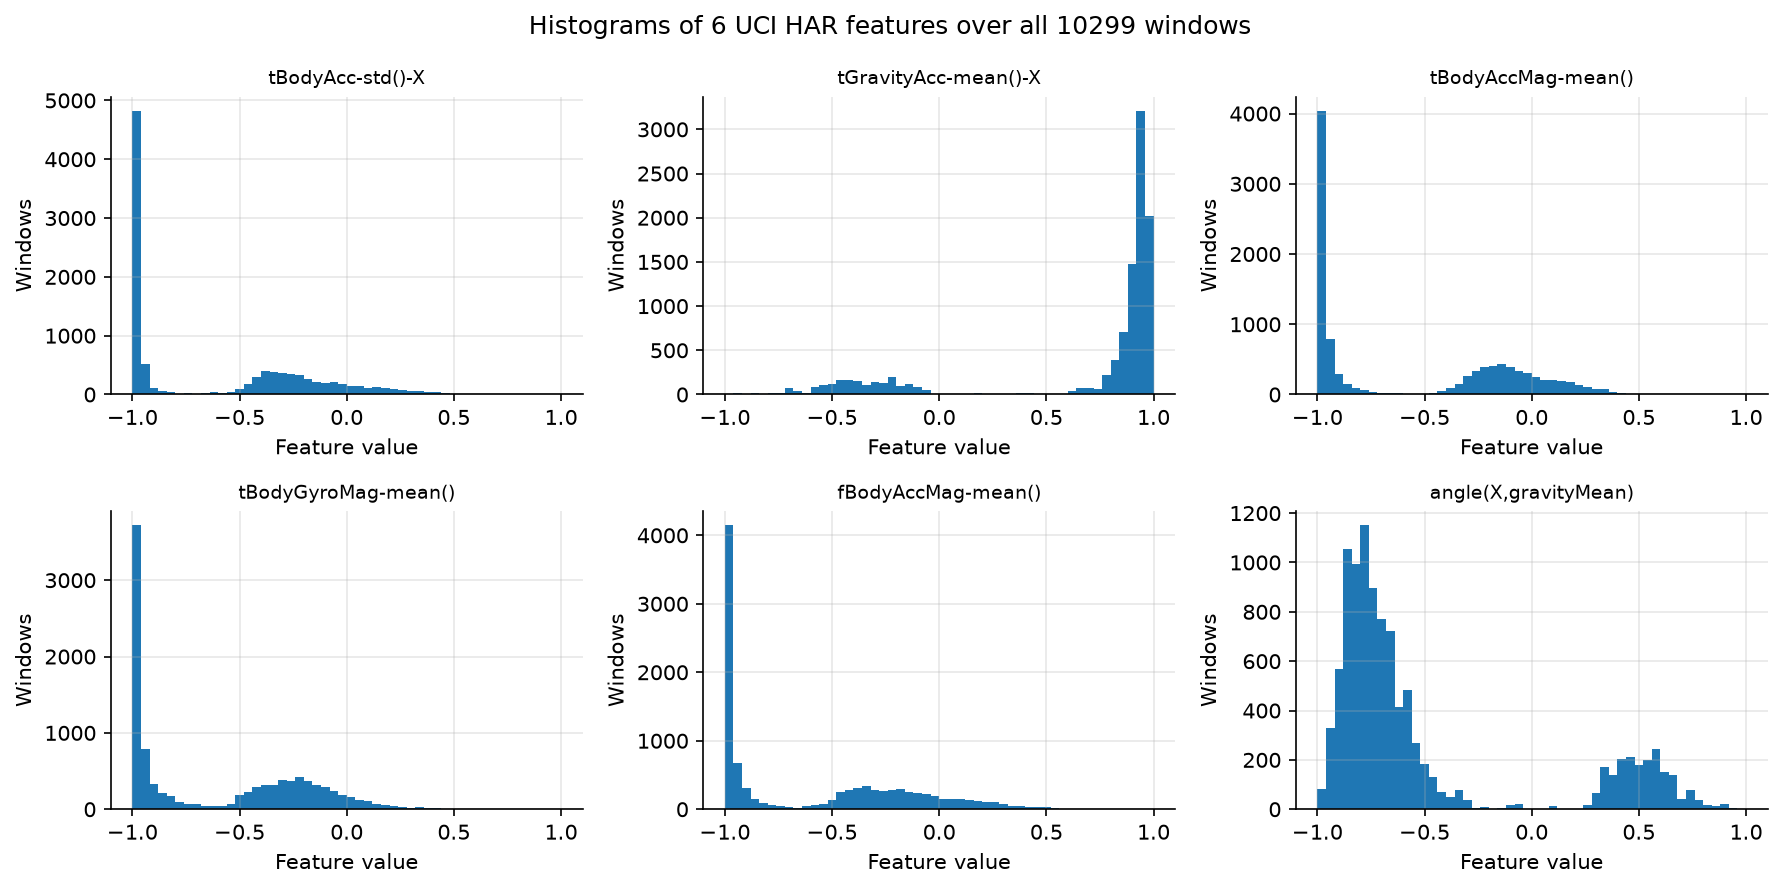

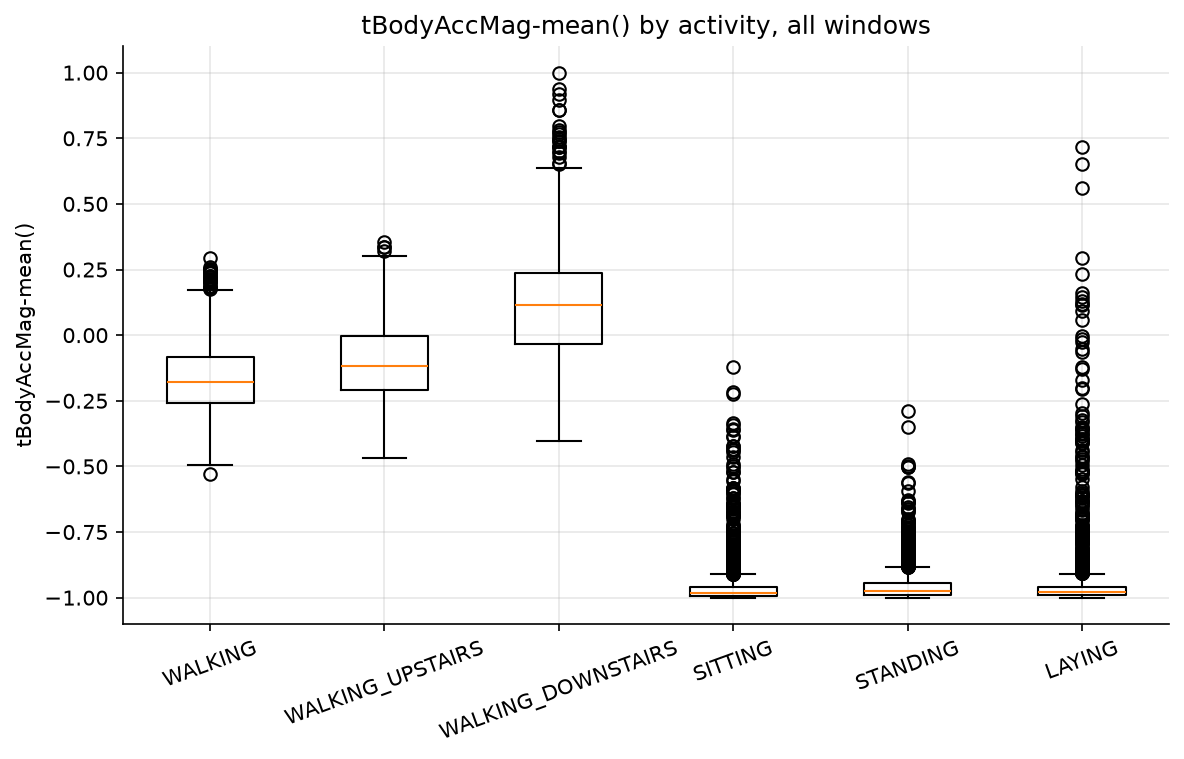

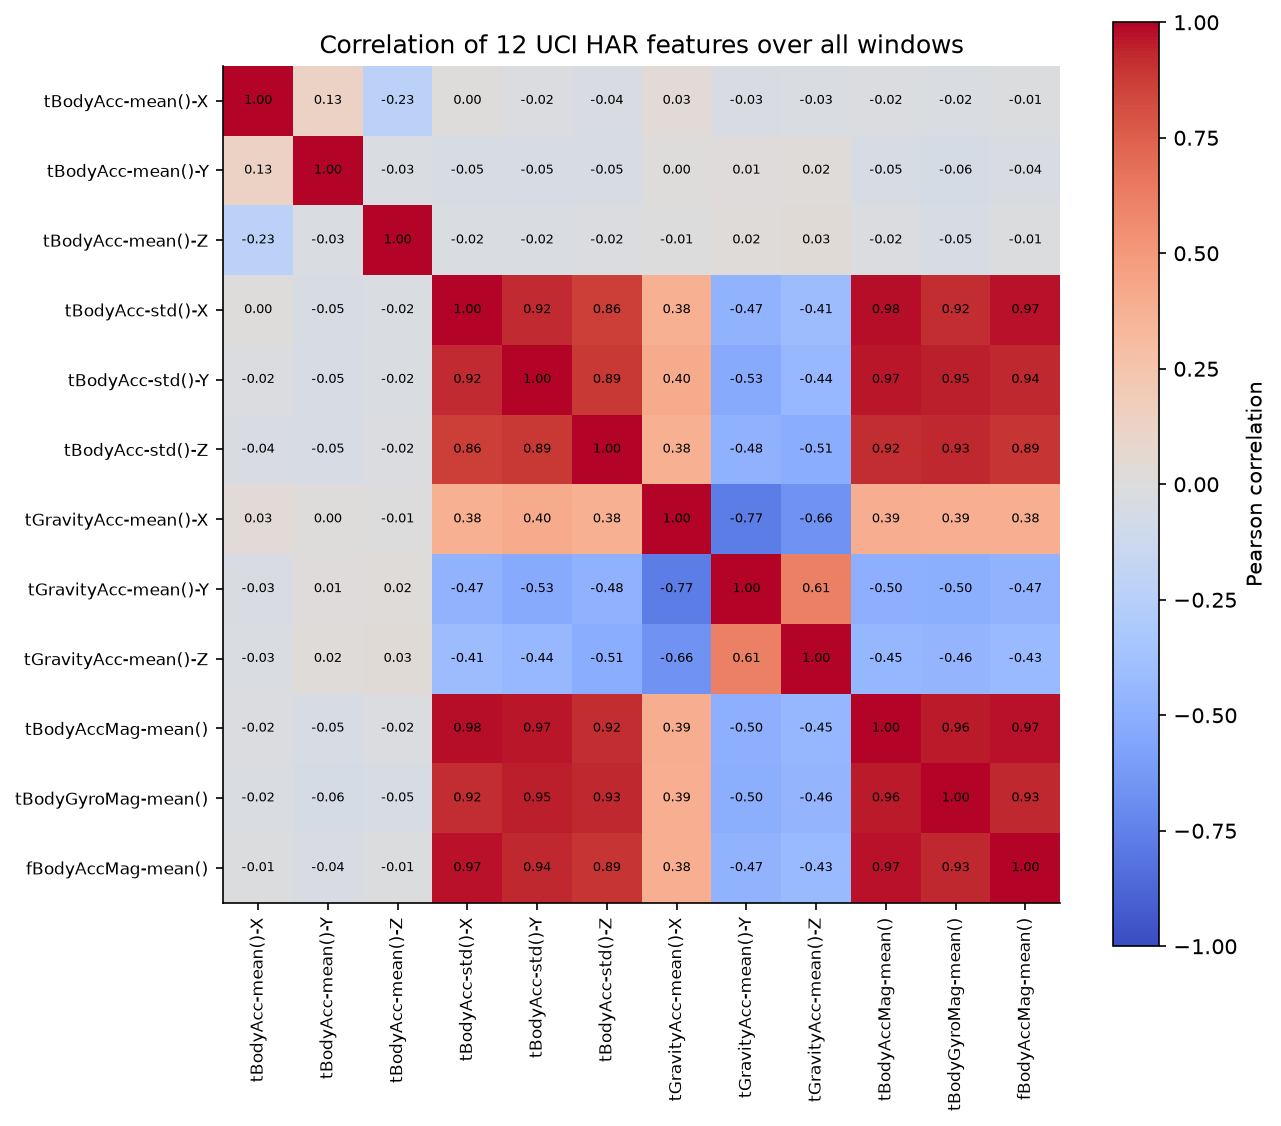

In [5]:
study.describeStatistics()
display(readCsv(study.resultsDirectory / "classDistribution.csv").head(10))
display(readCsv(study.resultsDirectory / "featureStatistics.csv").head(10))
for figureName in ["histograms", "boxPlot", "correlationHeatmap"]:
    display(Image(filename=str(study.figuresDirectory / f"{figureName}.png")))

## Preparing data

This step applies the scikit-learn transformers for scaling, normalization, binarization, standardization and label encoding to the training windows.
Each row of the table is one check, measured before and after the transformer.
It shows what each transformer changes in the data.

In [6]:
study.prepareData()
display(readCsv(study.resultsDirectory / "dataPreparation.csv").head(10))

,step,transformer,setting,check,before,after
0,scaling,MinMaxScaler,"feature_range (0, 1)",smallest value,-1.000000,0.000000
1,scaling,MinMaxScaler,"feature_range (0, 1)",largest value,1.000000,1.000000
2,normalization,Normalizer,norm l2,smallest window norm,10.687252,1.000000
3,normalization,Normalizer,norm l2,largest window norm,20.431493,1.000000
4,binarization,Binarizer,threshold 0,"share of values above the threshold, then shar...",0.197627,0.197627
5,standardization,StandardScaler,default,largest absolute feature mean,0.984059,0.000000
6,standardization,StandardScaler,default,smallest feature standard deviation,0.040808,1.000000
7,standardization,StandardScaler,default,largest feature standard deviation,0.751682,1.000000
8,label encoding,LabelEncoder,classes in sorted order,code of LAYING,NaN,0.000000
9,label encoding,LabelEncoder,classes in sorted order,code of SITTING,NaN,1.000000


## Feature selection

This step keeps the same number of features with SelectKBest, RFE, PCA and tree importance.
A logistic regression is then scored on each kept subset.
The table shows how much accuracy is left when the features are cut down, and which features each method kept first.

In [7]:
study.selectFeatures()
display(readCsv(study.resultsDirectory / "featureSelection.csv").head(10))
display(readCsv(study.resultsDirectory / "selectedFeatures.csv").head(10))

[ FOUNDATIONS : SELECTION SelectKBest MACRO F1 ] : 0.8155


[ FOUNDATIONS : SELECTION RFE MACRO F1 ] : 0.9201


[ FOUNDATIONS : SELECTION PCA MACRO F1 ] : 0.8730


[ FOUNDATIONS : SELECTION tree importance MACRO F1 ] : 0.8567


,method,setting,kept,testAccuracy,testMacroF1
0,SelectKBest,chi2 on unit range features,20,0.820156,0.815470
1,RFE,"logistic regression, step 0.1",20,0.920597,0.920139
2,PCA,standardized features,20,0.874788,0.873049
3,tree importance,"extra trees, 100 trees",20,0.859179,0.856700


,method,rank,kept,score
0,SelectKBest,1,fBodyAccJerk-entropy()-X,2769.376594
1,SelectKBest,2,fBodyAccJerk-entropy()-Y,2615.230651
2,SelectKBest,3,fBodyBodyAccJerkMag-entropy(),2381.916974
3,SelectKBest,4,fBodyAcc-entropy()-X,2302.615261
4,SelectKBest,5,fBodyAccJerk-entropy()-Z,2250.412677
5,SelectKBest,6,tBodyAccJerkMag-entropy(),1975.810367
6,SelectKBest,7,fBodyAcc-entropy()-Y,1952.410601
7,SelectKBest,8,fBodyAccMag-entropy(),1944.189813
8,SelectKBest,9,tBodyAcc-max()-X,1912.439303
9,SelectKBest,10,fBodyBodyGyroJerkMag-entropy(),1816.530082


## Classification algorithms

This step fits several classifiers on the standardized training windows and scores them on the official test windows.
The people in the test windows are not in the training windows, so the scores show how a model does on new people.
The table also shows how many seconds each fit took.

In [8]:
study.compareClassifiers()
display(readCsv(study.resultsDirectory / "classifierComparison.csv").head(10))

[ FOUNDATIONS : CLASSIFIER logisticRegression ACCURACY ] : 0.9545


[ FOUNDATIONS : CLASSIFIER supportVectorMachine ACCURACY ] : 0.9518


[ FOUNDATIONS : CLASSIFIER decisionTree ACCURACY ] : 0.8622
[ FOUNDATIONS : CLASSIFIER naiveBayes ACCURACY ] : 0.7703


[ FOUNDATIONS : CLASSIFIER randomForest ACCURACY ] : 0.9267


[ FOUNDATIONS : CLASSIFIER kNearestNeighbours ACCURACY ] : 0.8836


,classifier,setting,fitSeconds,testAccuracy,testMacroF1
0,logisticRegression,"lbfgs, max_iter 2000",32.954575,0.954530,0.954374
1,supportVectorMachine,"RBF kernel, C 1, gamma scale",1.306581,0.951815,0.951137
2,decisionTree,default,4.237442,0.862233,0.859469
3,naiveBayes,Gaussian,0.028118,0.770275,0.767235
4,randomForest,100 trees,5.759878,0.926705,0.925084
5,kNearestNeighbours,K 5,0.019284,0.883610,0.880526


## Regression algorithms

This step fits a linear regression and a random forest regressor on the diabetes data of scikit-learn.
Both models are scored on a part of the data that was held out.
A smaller error and a larger R2 mean a better fit.

In [9]:
study.runRegression()
display(readCsv(study.resultsDirectory / "regressionMetrics.csv").head(10))

,regressor,setting,meanAbsoluteError,meanSquaredError,r2
0,linearRegression,ordinary least squares,41.548507,2848.310651,0.484906
1,randomForest,100 trees,43.736396,3010.112568,0.455645


## Clustering algorithms

This step reduces a sample of the windows with PCA and groups them with k-means, mean shift and hierarchical clustering.
The grouping does not use the activity labels.
The adjusted Rand index then compares the groups with the real activities, where 1 means identical and 0 means chance level.

In [10]:
study.runClustering()
display(readCsv(study.resultsDirectory / "clustering.csv").head(10))

,method,setting,clusters,adjustedRandIndex
0,kMeans,"6 clusters, 10 initialisations",6,0.439494
1,meanShift,bandwidth 13.109 from quantile 0.2,10,0.320836
2,hierarchical,"6 clusters, ward linkage",6,0.391814


## Performance metrics

This step measures the logistic regression of the classifier step in more detail.
It writes a confusion matrix, a report per activity with precision, recall, F1 and specificity, and probability scores such as ROC AUC and log loss.
The figure shows which activities the model mixes up.

,activity,precision,recall,f1,specificity,support
0,WALKING,0.942639,0.993952,0.967615,0.987760,496
1,WALKING_UPSTAIRS,0.957082,0.946921,0.951974,0.991922,471
2,WALKING_DOWNSTAIRS,0.989950,0.938095,0.963325,0.998417,420
3,SITTING,0.968468,0.875764,0.919786,0.994300,491
4,STANDING,0.888508,0.973684,0.929148,0.973085,532
5,LAYING,0.998124,0.990689,0.994393,0.999585,537
6,macro average,0.957462,0.953184,0.954374,0.990845,2947
7,weighted average,0.956332,0.954530,0.954470,0.990539,2947


,metric,value
0,accuracy,0.954530
1,"ROC AUC, one against the rest, macro average",0.997536
2,log loss,0.138832


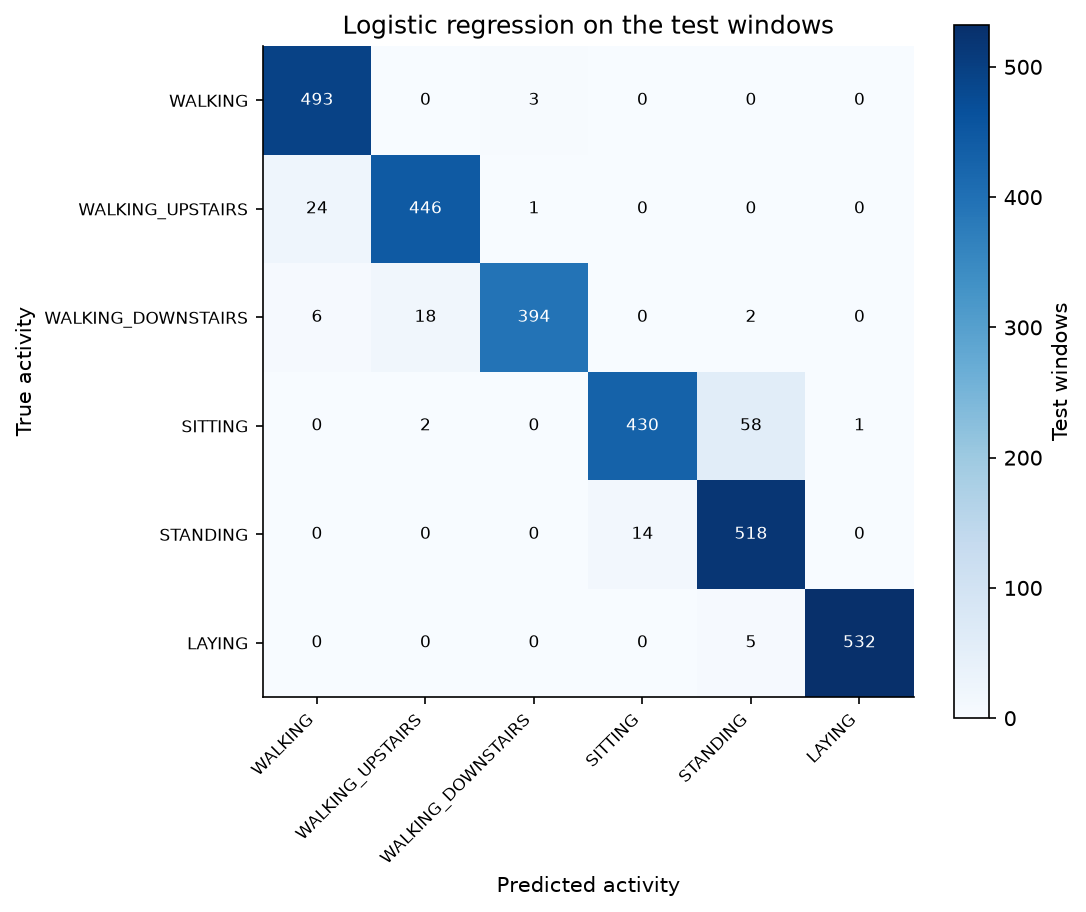

In [11]:
study.evaluateMetrics()
display(readCsv(study.resultsDirectory / "classificationReport.csv").head(10))
display(readCsv(study.resultsDirectory / "probabilityMetrics.csv").head(10))
display(Image(filename=str(study.figuresDirectory / "confusionMatrix.png")))

## Automatic workflows

This step builds a Pipeline and a FeatureUnion. A Pipeline chains steps such as scaling and a classifier into one model.
A FeatureUnion joins the output of two feature steps.
Both are scored with folds that keep every person in one fold, and then on the test windows.

In [12]:
study.buildPipelines()
display(readCsv(study.resultsDirectory / "pipelines.csv").head(10))

,workflow,setting,groupFoldMacroF1Mean,groupFoldMacroF1Std,testAccuracy,testMacroF1
0,Pipeline,StandardScaler then LinearDiscriminantAnalysis,0.950502,0.032333,0.962335,0.962618
1,FeatureUnion,"StandardScaler, then PCA ( 20 ) joined with Se...",0.900723,0.051000,0.901934,0.899972


## Improving performance: ensembles

This step fits bagging, a random forest, AdaBoost and a voting ensemble.
An ensemble combines many simple models into one.
The table shows whether combining models beats a single model.

In [13]:
study.compareEnsembles()
display(readCsv(study.resultsDirectory / "ensembleComparison.csv").head(10))

[ FOUNDATIONS : ENSEMBLE bagging ACCURACY ] : 0.8985


[ FOUNDATIONS : ENSEMBLE randomForest ACCURACY ] : 0.9267


[ FOUNDATIONS : ENSEMBLE adaBoost ACCURACY ] : 0.3492


[ FOUNDATIONS : ENSEMBLE voting ACCURACY ] : 0.9552


,ensemble,setting,fitSeconds,testAccuracy,testMacroF1
0,bagging,100 decision trees,142.232064,0.898541,0.896886
1,randomForest,100 trees,4.742133,0.926705,0.925084
2,adaBoost,50 decision stumps,24.233311,0.349169,0.202496
3,voting,"hard vote of logistic regression, decision tre...",6.075048,0.955209,0.954905


## Improving performance: grid search

This step tries several values of C and gamma for a support vector machine with a grid search.
The folds keep every person together, so the search does not learn from the people it is scored on.
The best setting is then refitted on all training windows and scored on the test windows.

In [14]:
study.tuneWithGroups()
display(readCsv(study.resultsDirectory / "gridSearch.csv").head(10))
display(readCsv(study.resultsDirectory / "gridSearchBest.csv").head(10))

[ FOUNDATIONS : GRID SEARCH BEST ] : C 100.0 gamma 0.0001


,C,gamma,groupFoldMacroF1Mean,groupFoldMacroF1Std,rank
0,1.0,0.0001,0.908983,0.049946,6
1,1.0,0.0010,0.926179,0.043821,5
2,1.0,0.0100,0.840272,0.062418,9
3,10.0,0.0001,0.929010,0.047997,3
4,10.0,0.0010,0.929729,0.038703,2
5,10.0,0.0100,0.844851,0.064062,7
6,100.0,0.0001,0.932172,0.045531,1
7,100.0,0.0010,0.927270,0.038340,4
8,100.0,0.0100,0.844851,0.064062,7


,C,gamma,groupFoldMacroF1Mean,testAccuracy,testMacroF1
0,100.0,0.0001,0.932172,0.956227,0.956087


## Run parameters

This step writes every setting and check value that was recorded during the run, together with the versions of Python and the libraries.
You can use it to compare two runs.

In [15]:
study.writeParameters()
display(readCsv(study.resultsDirectory / "runParameters.csv").head(10))

,section,parameter,value
0,run,randomSeed,42
1,run,nJobs,4
2,run,python,3.12.14
3,run,numpy,2.5.3
4,run,pandas,3.0.6
5,run,scipy,1.18.1
6,run,scikit-learn,1.9.1
7,run,matplotlib,3.11.2
8,selection,keptPerMethod,20
9,selection,eliminationStep,0.1
